# Lab 05: Solutions

## Semantic Segmentation ##
**1**

Write a program that does semantic segmentation of any image given as input by the user.
1. Load the pretrained ResNet-101 Fully Convolutional Netowrks
    * Hint: https://pytorch.org/vision/main/models/fcn.html
2. Load a generic image
    * Hint: https://static.independent.co.uk/s3fs-public/thumbnails/image/2018/04/10/19/pinyon-jay-bird.jpg
3. Now, that we have the image we need to preprocess it and normalize it. So, for the preprocessing steps, we:
    * Resize the image to `(256 x 256)`
    * CenterCrop it to `(224 x 224)`
    * Convert it to Tensor - all the values in the image becomes between `[0, 1]` from `[0, 255]`
    * Normalize it with the Imagenet specific values `mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]`
    * Lastly, we unsqueeze the image so that it becomes `[1 x C x H x W]` from `[C x H x W]` (we need a batch dimension while passing it to the model)
4. Pass the input through the model
5. Take the max index for each pixel position, which represents the class
6. Use the helper function to see the final segmented output
7. Move the steps from 2 to 6 this under one function in order to play with a few more images

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models
import torchvision.transforms as T

In [13]:
# Helper function.
def decode_segmap(image, nc=21):

  label_colors = np.array([(0, 0, 0),  # 0 = background
               # 1 = aeroplane, 2 = bicycle, 3 = bird, 4 = boat, 5 = bottle
               (128, 0, 0), (0, 128, 0), (128, 128, 0), (0, 0, 128), (128, 0, 128),
               # 6 = bus, 7 = car, 8 = cat, 9 = chair, 10 = cow
               (0, 128, 128), (128, 128, 128), (64, 0, 0), (192, 0, 0), (64, 128, 0),
               # 11 = dining table, 12 = dog, 13 = horse, 14 = motorbike, 15 = person
               (192, 128, 0), (64, 0, 128), (192, 0, 128), (64, 128, 128), (192, 128, 128),
               # 16 = potted plant, 17 = sheep, 18 = sofa, 19 = train, 20 = tv/monitor
               (0, 64, 0), (128, 64, 0), (0, 192, 0), (128, 192, 0), (0, 64, 128)])

  r = np.zeros_like(image).astype(np.uint8)
  g = np.zeros_like(image).astype(np.uint8)
  b = np.zeros_like(image).astype(np.uint8)

  for l in range(0, nc):
    idx = image == l
    r[idx] = label_colors[l, 0]
    g[idx] = label_colors[l, 1]
    b[idx] = label_colors[l, 2]

  rgb = np.stack([r, g, b], axis=2)

  return rgb

In [16]:
# Load the pretrained ResNet-101 Fully Convolutional Network.
model = models.segmentation.fcn_resnet101(pretrained=True).eval()
model = model.cuda()

/home/francesco/anaconda3/envs/nanovlm/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/francesco/anaconda3/envs/nanovlm/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


2026-04-21 17:08:01 URL:https://static.independent.co.uk/s3fs-public/thumbnails/image/2018/04/10/19/pinyon-jay-bird.jpg [182904/182904] -> "bird.png" [1]


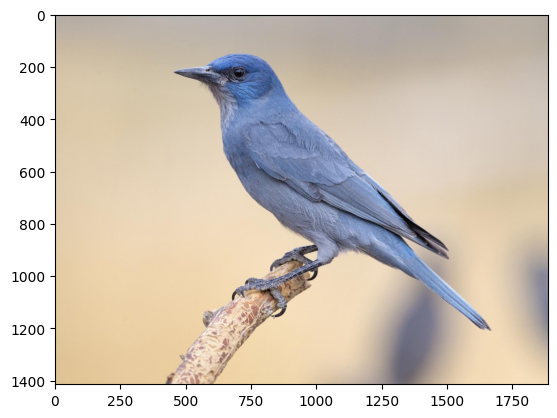

In [4]:
# Load a generic image.
!wget -nv https://static.independent.co.uk/s3fs-public/thumbnails/image/2018/04/10/19/pinyon-jay-bird.jpg -O bird.png
img = Image.open('./bird.png')

plt.imshow(img); plt.show()

In [14]:
# Apply the transformations needed.
data_transform = T.Compose([T.Resize(256),
                 T.CenterCrop(224),
                 T.ToTensor(),
                 T.Normalize(mean = [0.485, 0.456, 0.406],
                             std = [0.229, 0.224, 0.225])])
inp = data_transform(img).unsqueeze(0)

In [17]:
# Pass the input through the model.
inp = inp.cuda()
out = model(inp)['out']
print(out.shape)

torch.Size([1, 21, 224, 224])


In [18]:
# Take the max index for each pixel position, which represents the class.
pred = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()

print(pred.shape)
print(np.unique(pred))

(224, 224)
[0 3]


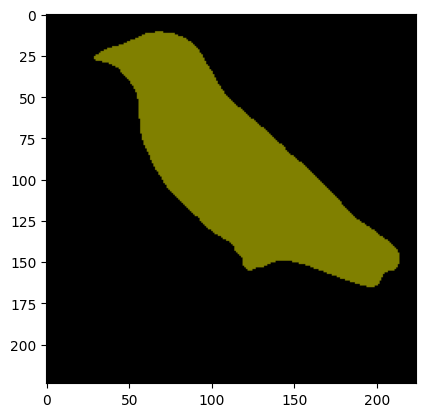

In [19]:
# Use the helper function to see the final segmented output.
rgb = decode_segmap(pred)
plt.imshow(rgb); plt.show()

In [24]:
# Move the steps from 2 to 6 this under one function in order to play with a few more images.
def segment(net, path, show_orig=True, dev='cuda'):
  img = Image.open(path)
  
  if show_orig: 
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
  trf = T.Compose([T.Resize(256),
                   T.CenterCrop(224),
                   T.ToTensor(), 
                   T.Normalize(mean = [0.485, 0.456, 0.406], 
                               std = [0.229, 0.224, 0.225])])
  inp = trf(img).unsqueeze(0).to(dev)
  out = net.to(dev)(inp)['out']
  om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
  rgb = decode_segmap(om)
  
  plt.imshow(rgb)
  plt.axis('off')
  plt.show()

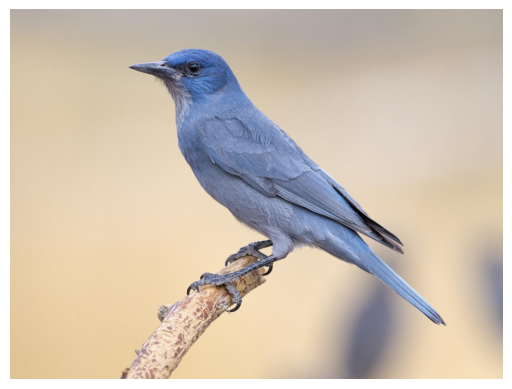

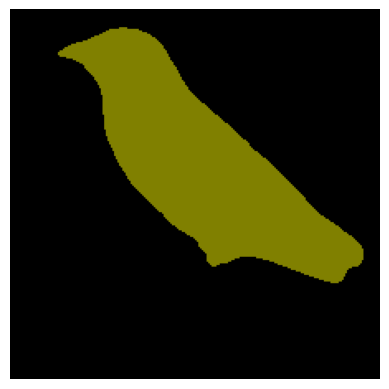

In [23]:
segment(model, './bird.png', show_orig=True)